# Kapittel 1: Hvorfor fysikalsk kjemi? – fra molekyler til verden rundt oss

## 1.1 Fysikalsk kjemi i hverdagen

Fysikalsk kjemi er læren om de grunnleggende kreftene og bevegelsene som styrer molekyler, og om hvordan summen av disse gir opphav til de egenskapene vi kan observere og måle.

```{admonition} Tenk etter
:class: tip
- Kan du nevne tre fenomener i hverdagen som du tror kan forklares med fysikalsk kjemi?
- Hva tror du menes med at «tilfeldighet kan gi forutsigbarhet»?
```

## 1.2 Molekyler i bevegelse

Et glass vann inneholder rundt 10^25 vannmolekyler. Hvert av dem beveger seg med en hastighet på flere hundre meter i sekundet.

```{admonition} Tenk etter
:class: tip
- Hvis molekyler alltid er i bevegelse, hva betyr det da at et stoff har «0 K» temperatur?
- Hva tror du skjer med trykket i en gass hvis temperaturen øker, men volumet er det samme?
```

## 1.3 Fra tilfeldighet til forutsigbarhet

Kast en mynt én gang. Utfallet er tilfeldig. Kast den hundre ganger – andelen kron og mynt nærmer seg 50/50.

La oss teste med en enkel simulering av tilfeldig vandring («random walk»):

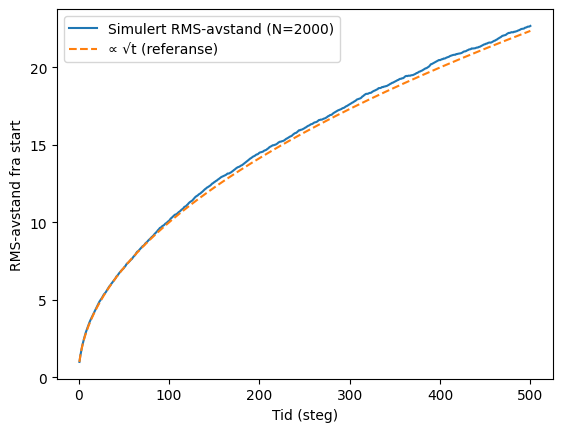

In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
N = 2000
T = 500
step_size = 1.0

dirs = np.random.randint(0, 4, size=(T, N))
dx = (dirs == 1).astype(float) - (dirs == 3).astype(float)
dy = (dirs == 0).astype(float) - (dirs == 2).astype(float)

x = np.cumsum(dx * step_size, axis=0)
y = np.cumsum(dy * step_size, axis=0)
r2 = x**2 + y**2
r_rms = np.sqrt(np.mean(r2, axis=1))

t = np.arange(1, T+1)
theory = np.sqrt(t) * step_size

plt.plot(t, r_rms, label="Simulert RMS-avstand (N=2000)")
plt.plot(t, theory, "--", label="∝ √t (referanse)")
plt.xlabel("Tid (steg)")
plt.ylabel("RMS-avstand fra start")
plt.legend()
plt.show()


```{admonition} Tenk etter
:class: tip
- Hvorfor vokser middelavstanden omtrent som √t selv om hver enkelt bane er «kaotisk»?
- Hva skjer med kurven hvis du endrer antall partikler N?
```

## 1.4 Molekylære drivkrefter

En dråpe blekk sprer seg i vann. La oss simulere dette med en enkel 1D diffusjonsmodell:

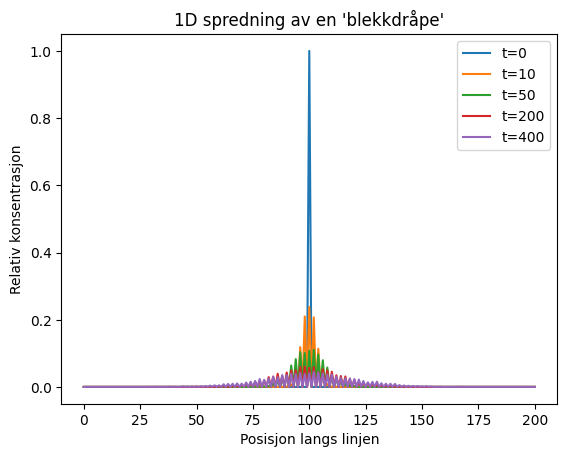

In [2]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)
L = 201
steps = 400
particles = 5000
x = np.full(particles, L//2, dtype=int)

snapshots = [0, 10, 50, 200, 400]
plt.figure()
for t in range(steps+1):
    if t in snapshots:
        hist = np.bincount(x, minlength=L).astype(float)
        hist /= np.sum(hist)
        plt.plot(hist, label=f"t={t}")
    moves = np.random.rand(particles) < 0.5
    x[moves] -= 1
    x[~moves] += 1
    x = np.clip(x, 0, L-1)
plt.xlabel("Posisjon langs linjen")
plt.ylabel("Relativ konsentrasjon")
plt.title("1D spredning av en 'blekkdråpe'")
plt.legend()
plt.show()


```{admonition} Tenk etter
:class: tip
- Hvorfor sprer blekket seg, men samler seg aldri spontant igjen?
- Kan du nevne et biologisk eksempel som bygger på samme prinsipp?
```

## 1.5 Energi og stabilitet – en smakebit

Når is smelter ved romtemperatur... La oss simulere en varmekurve:

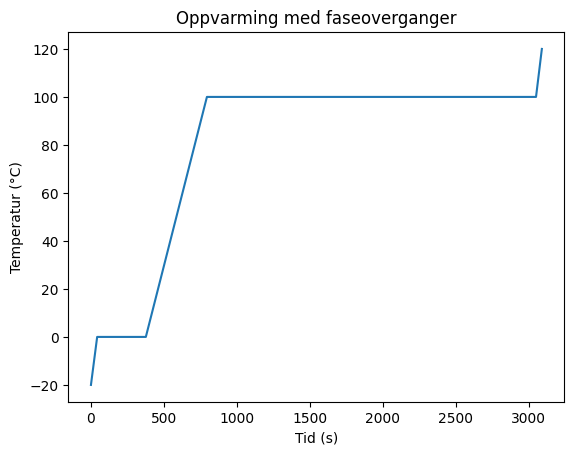

In [3]:

import numpy as np
import matplotlib.pyplot as plt

m = 0.1
c_solid, c_liquid, c_gas = 2100, 4180, 2000
T_melt, T_boil = 0.0, 100.0
L_fus, L_vap = 334000, 2256000

Qdot = 100.0
dt = 0.2
T0 = -20.0
T_max = 120.0

state = 0
T = T0
Q_latent_left = 0.0
times, temps = [], []
t = 0.0

while T < T_max:
    times.append(t)
    temps.append(T)
    Q_in = Qdot * dt
    if state == 0:
        if T < T_melt:
            dT = Q_in / (m * c_solid)
            T = min(T + dT, T_melt)
            Q_in = 0
        if T >= T_melt:
            state = 1
            Q_latent_left = m * L_fus
    if state == 1:
        if Q_latent_left > 0:
            dq = min(Q_in, Q_latent_left)
            Q_latent_left -= dq
            Q_in -= dq
            T = T_melt
        else:
            if T < T_boil:
                dT = Q_in / (m * c_liquid)
                T = min(T + dT, T_boil)
                Q_in = 0
            if T >= T_boil:
                state = 2
                Q_latent_left = m * L_vap
    if state == 2:
        if Q_latent_left > 0:
            dq = min(Q_in, Q_latent_left)
            Q_latent_left -= dq
            Q_in -= dq
            T = T_boil
        else:
            dT = Q_in / (m * c_gas)
            T += dT
    t += dt

plt.plot(times, temps)
plt.xlabel("Tid (s)")
plt.ylabel("Temperatur (°C)")
plt.title("Oppvarming med faseoverganger")
plt.show()


```{admonition} Tenk etter
:class: tip
- Hvorfor står temperaturen stille i platåene selv om vi tilfører varme?
- Hva slags energi går med til å smelte is?
```

## 1.6 Et helhetlig eksempel: vann som case

Vann kombinerer alt vi har sett: molekylære bindinger, makroskopiske egenskaper, og symbolske ligninger.

```{admonition} Tenk etter
:class: tip
- Hva er forskjellen på å forklare «is smelter» på molekylnivå, makronivå og symbolnivå?
- Hvilken forklaring opplever du som mest tilfredsstillende?
```

## 1.7 Oppsummering

I dette kapittelet har vi sett at molekyler er i konstant, tilfeldig bevegelse, men at summen gir forutsigbare mønstre.

```{admonition} Tenk etter
:class: tip
- Hvordan kan fysikalsk kjemi forklare både dagligdagse fenomener og avanserte prosesser?
```